## Week 7 - Exploratory Data Analysis

Any statistical modeling project (or any data analysis project, for that matter) must start with Exploratory Data Analysis (or EDA). Recall from your 'Tidyverse Skills for Data Science' textbook that there are 7 steps in a data science project:  

• Define the question you want to ask the data  
• Get the data  
• Clean the data  
• Explore the data  
• Fit statistical models  
• Communicate the results  
• Make your analysis reproducible  

We have already covered parts 2 and 3 - now we will focus on part 4, Explore the Data.  
### Exploratory Data Analysis (EDA)
So what do we mean by EDA? According to our 'Tidyverse Skills for Data Science' textbook, Descriptive and Exploratory analyses develop simple summaries about the data you're working with and how the variables might relate to each other. This step can help to discover new questions about the data, it can help to spot any data issues (e.g., irregularities, anomalies, outliers). It can also help us think about whether any transformations or normalizations might be needed. It can also help us think about what kind of statistical model we may want to fit.

The use of descriptive statistics, such as measures of central tendency (i.e., mean, median, mode) and measures of variability (i.e., range, standard deviations, or variance), are all critical parts of an EDA. 

### Libraries needed 
We will need tidyverse and ggplot2


In [3]:
library(tidyverse)
library(ggplot2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### Reading in the Data
This dataset comes from Sommer et al. (2018), "Comparing apples to apples: an environmental criminology analysis of the effects of heat and rain on violent crimes in Boston."  

In [4]:
data <- read_csv("data/weather_crimes_Boston.csv")

Rows: 1695 Columns: 58


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): Day_Wk, Season
dbl  (55): nb_crimes, nb_aggravated, nb_simple, nb_vandalism, nb_robbery, nb...
date  (1): Date



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


An overview of what these variables stand for (from what I could surmise, as no metadata were included with the data files)
  - Date: date in YYYY-MM-DD  
  - Day_Wk: day of the week  
  - nb_crimes: number of total crimes  
  - nb... : number of type of crimes  
  - TEMP: temperature in C  
  - TMAX_C: maximum temperature in C  
  - TMIN_C: minimum temperature in C  
  - DEWP: dewpoint  
  - VISIB: visibility  
  - WIND: wind speed  
  - PRCP: precipitation  
  - y20XX: year of data (0/1)  
  - year: year of data  
  - Friday...Weekend: day of week of data (0/1)  
  - _lag: series of lag variables  
  - Season: season of date  
  - Summer...Spring: Season (0/1)  
  - heat.index: heat index  
  - SNOW: whether there was recorded SNOW  

Let's first use our trusty functions `glimpse` etc. to take a look at what's in the data:

In [12]:
glimpse(data)

Rows: 1,695
Columns: 58
$ Date            <date> 2012-07-08, 2012-07-09, 2012-07-10, 2012-07-11, 2012-…
$ Day_Wk          <chr> "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday"…
$ nb_crimes       <dbl> 177, 285, 263, 246, 251, 264, 213, 235, 248, 279, 227,…
$ nb_aggravated   <dbl> 8, 6, 11, 8, 7, 11, 10, 3, 8, 9, 4, 3, 9, 4, 6, 4, 0, …
$ nb_simple       <dbl> 19, 17, 20, 15, 12, 19, 20, 20, 20, 22, 12, 7, 19, 23,…
$ nb_vandalism    <dbl> 13, 14, 15, 17, 22, 13, 13, 16, 11, 13, 9, 14, 20, 20,…
$ nb_robbery      <dbl> 7, 7, 3, 2, 3, 8, 6, 7, 8, 1, 5, 2, 9, 3, 6, 10, 3, 6,…
$ nb_larceny      <dbl> 31, 48, 43, 35, 49, 35, 29, 50, 46, 35, 32, 49, 48, 42…
$ nb_fraud        <dbl> 3, 11, 10, 4, 9, 10, 3, 2, 9, 8, 5, 6, 7, 5, 4, 11, 13…
$ nb_selected     <dbl> 42, 37, 49, 43, 43, 43, 46, 39, 41, 48, 27, 27, 49, 48…
$ TEMP            <dbl> 26.44444, 24.33333, 22.72222, 23.16667, 24.50000, 25.7…
$ TMAX_C          <dbl> 31.72222, 31.72222, 28.88889, 28.27778, 30.00000, 32.2…
$ TMIN_C        

### Exploring Missingness in the Data 
As the 'Tidyverse' textbook describes, missing data can cause a whole host of problems in data analysis. You've already experienced some of these challenges, for example, the need to specify `na.rm=TRUE` so that you can calculate summary statistics like `mean`. Therefore, it's best to get an understanding of missingness in your data from the get-go. In R, we usually specify a missing value with "NA", but as we've seen in the real world, sometimes different data providers/authors will code missingness in different ways - with blank cells, N/A, na, -999, etc. 
From when you used the `glimpse` function above, what variables can you see have missing values? How can you tell?

## IN CLASS: We can also use our tidyverse functions `summarise_all`:

In [4]:
data %>% summarise_all(funs(sum(is.na(.))))
data %>% summarise(across(everything(),~ sum(is.na(.))))

ERROR: Error in data %>% summarise_all(funs(sum(is.na(.)))): could not find function "%>%"


## IN CLASS: How might you calculate the proportion of missingness for each variable?

In [13]:
data %>% select_if(is.numeric) %>% summarise_all(funs(mean(is.na(.))))

data %>% summarise(across(everything(),~ mean(is.na(.))))

Warning message:
“`funs()` was deprecated in dplyr 0.8.0.
ℹ Please use a list of either functions or lambdas:

# Simple named list: list(mean = mean, median = median)

# Auto named with `tibble::lst()`: tibble::lst(mean, median)

# Using lambdas list(~ mean(., trim = .2), ~ median(., na.rm = TRUE))”


nb_crimes,nb_aggravated,nb_simple,nb_vandalism,nb_robbery,nb_larceny,nb_fraud,nb_selected,TEMP,TMAX_C,⋯,LastDayMonth,FirstDayMonth,MidDayMonth,SNOW,Events,Holidays,Snow,Rain,WindxRain,WindxHeatIndex
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


Date,Day_Wk,nb_crimes,nb_aggravated,nb_simple,nb_vandalism,nb_robbery,nb_larceny,nb_fraud,nb_selected,⋯,LastDayMonth,FirstDayMonth,MidDayMonth,SNOW,Events,Holidays,Snow,Rain,WindxRain,WindxHeatIndex
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


There are also a few packages that have been developed to visualize missingness:

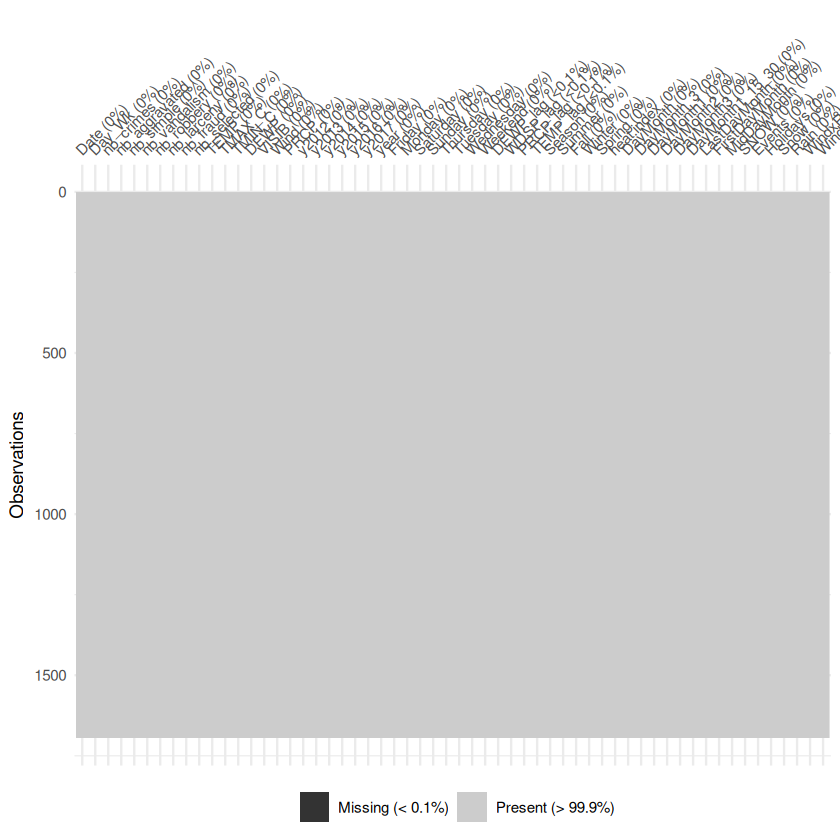

In [14]:
#install.packages("naniar")
library(naniar)

# visualize missingness
vis_miss(data)

Wow! It looks like our data are pretty complete. How can you tell?

*Work up to here and we will pick up from here for Class*

### Describing the Data's Shape
Determining the 'shape' of your data or a variable in question is essential because statistical methods used for inference often require your data to be distributed in a certain manner (i.e., normal distribution) before they can be applied to the data.   

What do we mean by shape? You'll want to consider how the observations within the variable's range are distributed - are they clustered towards the middle, are they skewed in some way, are the spread out or clustered together? 

How can we describe a data's shape? **Hint: histograms! Plot the distribution of `nb_crimes`:

In [6]:
data %>% 
  ggplot(aes(x=nb_crimes)) +
  geom_density() +
  theme_classic()

ERROR: Error in data %>% ggplot(aes(x = nb_crimes)): could not find function "%>%"


How would you describe the shape of `nb_crimes` distribution? Is this variable skewed? Do you see any outliers? 

What about for some other crime types? Make a boxplot that shows the distributions of all of the crime subtypes. Hint: don't forget to `pivot_longer`!


In [7]:
data %>% pivot_longer(c(nb_aggravated:nb_fraud), names_to="crime_type", values_to="value") %>%
  ggplot(aes(x=crime_type, y=value, fill=crime_type)) +
  geom_boxplot()+
  theme_classic()

ERROR: Error in data %>% pivot_longer(c(nb_aggravated:nb_fraud), names_to = "crime_type", : could not find function "%>%"


What does this tell us that we didn't see from the `nb_crimes` distribution? Are there any outliers that you observe in any of the crime types? 

By default, boxplots flag "outliers" as any observations beyond 1.5 times the interquartile range (IQR or the length of the box), which is the distance between the first and third quartiles. This provides a mathematical way to identify potential outliers, making them easy to spot visually. However, it's ultimately up to you, the analyst, to decide whether an observation should be removed.

In [8]:
data %>% ggplot(aes(x=nb_robbery)) +
  geom_density()+
  theme_classic()

ERROR: Error in data %>% ggplot(aes(x = nb_robbery)): could not find function "%>%"


### Calculating summary statistics
You will want to calculate summary statistics for your data that give you a sense of the central tendency (e.g., mean, median, mode), as well as the variability in the data (e.g., variance and standard deviation).

We've already practiced how to calculate some of these measures with `mean` and `sd` using the `summarise` function. Try calculating the mean and sd for a few of the crime types (i.e., nb_aggravated or nb_robbery) - on average, which types of crimes are more common?

In [9]:
data %>% dplyr::summarise(mean=mean(nb_aggravated), sd=sd(nb_aggravated))

ERROR: Error in data %>% dplyr::summarise(mean = mean(nb_aggravated), sd = sd(nb_aggravated)): could not find function "%>%"


Now try using the `summary` base R function:

In [15]:
summary(data)

      Date               Day_Wk            nb_crimes   nb_aggravated   
 Min.   :2012-07-08   Length:1695        Min.   :110   Min.   : 0.000  
 1st Qu.:2013-09-04   Class :character   1st Qu.:215   1st Qu.: 3.000  
 Median :2014-11-02   Mode  :character   Median :239   Median : 5.000  
 Mean   :2014-11-02                      Mean   :236   Mean   : 5.438  
 3rd Qu.:2015-12-30                      3rd Qu.:260   3rd Qu.: 7.000  
 Max.   :2017-02-26                      Max.   :343   Max.   :20.000  
                                                                       
   nb_simple      nb_vandalism     nb_robbery       nb_larceny   
 Min.   : 2.00   Min.   : 1.00   Min.   : 0.000   Min.   : 5.00  
 1st Qu.:11.00   1st Qu.: 9.00   1st Qu.: 3.000   1st Qu.:27.00  
 Median :14.00   Median :12.00   Median : 4.000   Median :32.00  
 Mean   :14.47   Mean   :12.35   Mean   : 4.297   Mean   :32.64  
 3rd Qu.:17.00   3rd Qu.:15.00   3rd Qu.: 6.000   3rd Qu.:39.00  
 Max.   :32.00   Max.   :34.

We can also use the `skim` function in the `skimr` package for a quick summary:

In [10]:
# install.packages("skimr")
options(scipen=99999)
library(skimr)
skimmed <- skim(data)
print(skimmed, strip_metadata = FALSE)

# Viewing the summary statistics in a table 
data %>% select_if(is.numeric) %>% skim() %>% as_tibble()

skim(data) %>% filter(skim_variable == "nb_crimes")

ERROR: Error in library(skimr): there is no package called ‘skimr’


### Evaluating relationships between variables
You may also want to take a look at relationships between variables. You could individually create bivariate scatterplots to see whether there are any correlations (remember - the correlation coefficient ranges between -1 and 1, with -1 meaning a perfectly negative correlation with 1 meaning a perfectly positive correlation) in your continuous variables. 

Pick two variables to plot using ggplot in a scatterplot:

In [12]:
ggplot(data, aes(x=TEMP, y=nb_crimes)) +
  geom_point() +
  theme_bw()

ERROR: Error in ggplot(data, aes(x = TEMP, y = nb_crimes)): could not find function "ggplot"


What do you think? Is there enough of a correlation to think that there might be a relationship between the two variables? What are ways we might be able to evaluate the strength of this relationship?

#### Using GGally for Quick Correlational Analysis
A package I like to use is GGally, which has a few built-in functions to explore your data. Since our data have many variables, let's just select a few to consider. The first function is `ggcorr`, which will plot a heat map that will allow us to see which variables might be correlated.

[1] "Date"            "Day_Wk"          "nb_crimes"       "nb_aggravated"  
 [5] "nb_simple"       "nb_vandalism"    "nb_robbery"      "nb_larceny"     
 [9] "nb_fraud"        "nb_selected"     "TEMP"            "TMAX_C"         
[13] "TMIN_C"          "DEWP"            "VISIB"           "Wind"           
[17] "PRCP"            "y2012"           "y2013"           "y2014"          
[21] "y2015"           "y2016"           "y2017"           "year"           
[25] "Friday"          "Monday"          "Saturday"        "Sunday"         
[29] "Thursday"        "Tuesday"         "Wednesday"       "Weekend"        
[33] "DEWP_lag"        "WDSP_lag"        "PRCP_lag"        "TEMP_lag"       
[37] "Season"          "Summer"          "Fall"            "Winter"         
[41] "Spring"          "heat.index"      "DayMonth"        "DayMonth_3"     
[45] "DayMonth1"       "DayMonth2"       "DayMonth3"       "DayMonth1_15_30"
[49] "LastDayMonth"    "FirstDayMonth"   "MidDayMonth"     "SNOW"           
[53] "Events"          "Holidays"        "Snow"            "Rain"           
[57] "WindxRain"       "WindxHeatIndex"

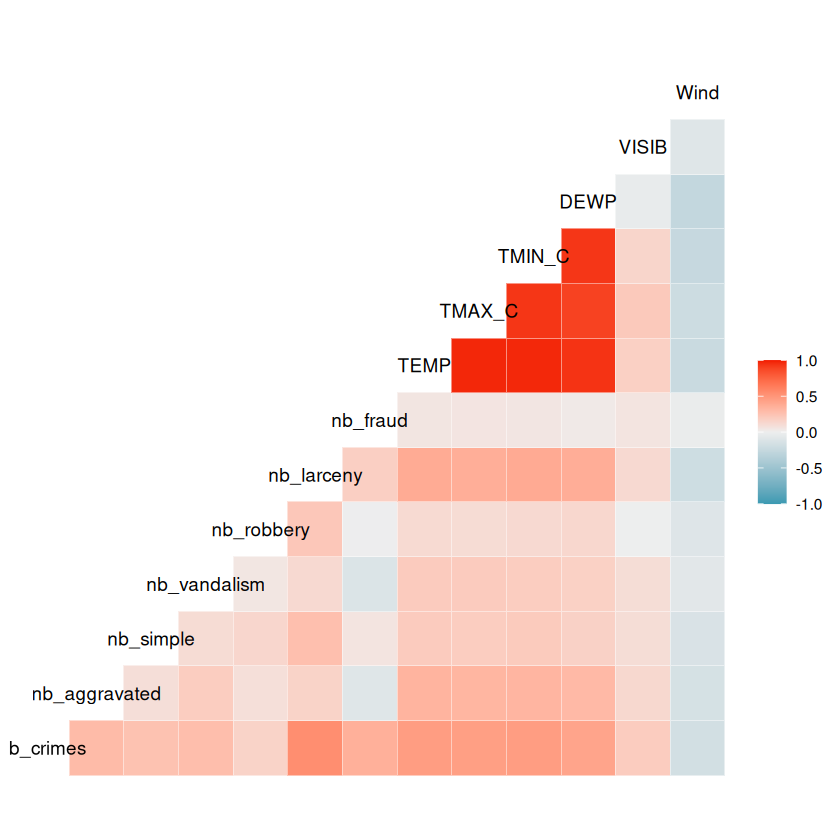

In [16]:
names(data)
# install.packages("GGally")
library(GGally)
data %>% dplyr::select(nb_crimes:nb_fraud, TEMP:Wind) %>%
  ggcorr()

Question: what does this plot tell you about the variables we selected? What insights can you glean here?

The `GGally` library also has a scatterplot matrix function called `ggpairs` that allows us to view many bivariate scatterplots at once. This is an important function because it will help us identify variables that we may want to include in a statistical inference model later. Since there are 

In [14]:
data %>% dplyr::select(nb_crimes:nb_fraud, TEMP:Wind) %>% ggpairs() # if you get an error trying to run this in the notebook itself, try pasting the code directly into the console.

ERROR: Error in data %>% dplyr::select(nb_crimes:nb_fraud, TEMP:Wind) %>% ggpairs(): could not find function "%>%"


Question: which variables are highly correlated? Which ones are not? How do we measure the strength of the correlation? 

## IN CLASS Practice EDA Questions
Exploring larceny crimes - is this type of crime truly much more common than other types, or are there outliers that we should consider removing?

In [20]:
data_long <- data %>% pivot_longer(c(nb_aggravated:nb_fraud), names_to="crime_type", 
             values_to="value") %>%
             dplyr::select(crime_type, value, Date, Season, TEMP:PRCP) 

What might explain the outliers in the larceny crimes? What about seasonality?

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


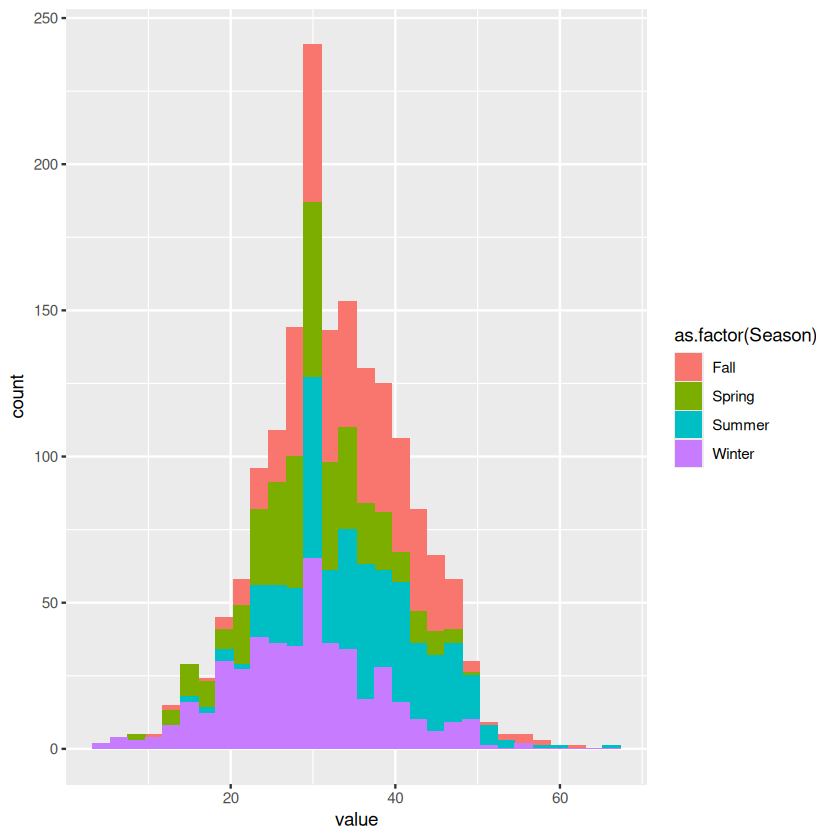

In [21]:
# plot a histogram that can helps us focus in on some of the outliers. Perhaps there's a seasonal difference? How could we tell?
data_long %>% filter(crime_type == "nb_larceny") %>%
  ggplot(aes(x=value, fill=as.factor(Season))) +
  geom_histogram()

It's clear that the outlier - a day with more than 60 larceny crimes (ie theft of personal property) falls in Summer and then compared to Winter, there are far fewer larcenies occurring. 

How could we evaluate whether these differences are actually significant?

In [22]:
# use a linear regression 
model <- lm(value ~ Season, data = data_long %>% filter(crime_type=="nb_larceny"))
summary(model)

# basically same as a Chi-square test or looking at differences between group means
# Chi-square test:
df_larceny <- data_long %>% filter(crime_type == "nb_larceny")

# Create a contingency table of season vs number of larceny crimes
larceny_table <- table(df_larceny$Season)

# Perform a chi-square test
chisq.test(larceny_table) # There is a statistically significant difference in the number of larceny crimes across seasons.This means the number of larceny crimes varies by season in a way that is unlikely due to random chance.


Call:
lm(formula = value ~ Season, data = data_long %>% filter(crime_type == 
    "nb_larceny"))

Residuals:
    Min      1Q  Median      3Q     Max 
-24.088  -5.333   0.029   5.029  30.667 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   35.0879     0.3787  92.663   <2e-16 ***
SeasonSpring  -5.2319     0.5663  -9.239   <2e-16 ***
SeasonSummer   1.2454     0.5455   2.283   0.0226 *  
SeasonWinter  -6.1169     0.5373 -11.385   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8.077 on 1691 degrees of freedom
Multiple R-squared:  0.1362,	Adjusted R-squared:  0.1347 
F-statistic: 88.87 on 3 and 1691 DF,  p-value: < 2.2e-16



	Chi-squared test for given probabilities

data:  larceny_table
X-squared = 11.145, df = 3, p-value = 0.01097


Ask students whether they might have any other hypotheses:
- perhaps one of the weather variables has more of an effect than others?
- perhaps some crime types are more sensitive to weather effects than others?
- perhaps holidays or days of the week (weekends vs. weekdays) might have an effect
- perhaps a given year was worse than another?
- what about interaction terms? There are a few included in the data frame (WindxRain and WindxHheatIndex). What about PRCP and Heat? Have them create this interaction term.

Have them explore some of these questions in their groups.